# Step 06 - Render Figures

Build each figure with the ggplot2/patchwork renderer in `06_figures.R`, preview it inline at its
saved aspect ratio, and write PNG/PDF to `Analysis_R/outputs/`. The final cell calls
`render_all_figures_r()` -- the batch entry point used by `run_step_06_render_figures.R` -- as an
end-to-end check that the orchestrator matches the figures previewed above.

In [1]:
source("../R/00_config.R")
source("../R/01_load_data.R")
source("../R/03_reliability_tables.R")
source("../R/04_fig1_tables.R")
source("../R/05_sensitivity_tables.R")
source("../R/06_figures.R")

In [ ]:
config <- analysis_config(); ensure_dir(config$output_dir)
stopifnot(inputs_available(config))
required_csvs <- c("BA_ICC_CCC_Statistics.csv", "Fig5_ICC_CCC_Sex_Menstrual_Stats.csv",
                   "Fig6_ICC_CCC_Exclude_Unmatched_Females_Stats.csv",
                   "Fig1_ANOVA_Time_Visit_Results.csv", "Fig1_Posthoc_Bonferroni.csv")
stopifnot(all(file.exists(file.path(config$output_dir, required_csvs))))

df <- load_tcd_data(config)
stats_df   <- read.csv(file.path(config$output_dir, "BA_ICC_CCC_Statistics.csv"), check.names = FALSE, stringsAsFactors = FALSE)
fig6_df    <- read.csv(file.path(config$output_dir, "Fig6_ICC_CCC_Exclude_Unmatched_Females_Stats.csv"), check.names = FALSE, stringsAsFactors = FALSE)
sex_df     <- read.csv(file.path(config$output_dir, "Fig5_ICC_CCC_Sex_Menstrual_Stats.csv"), check.names = FALSE, stringsAsFactors = FALSE)
anova_df   <- read.csv(file.path(config$output_dir, "Fig1_ANOVA_Time_Visit_Results.csv"), check.names = FALSE, stringsAsFactors = FALSE)
posthoc_df <- read.csv(file.path(config$output_dir, "Fig1_Posthoc_Bonferroni.csv"), check.names = FALSE, stringsAsFactors = FALSE)

# Preview each figure inline at its true saved aspect ratio
preview <- function(p, name) {
  dims <- figure_dims[[name]]
  options(repr.plot.width = dims[["width"]], repr.plot.height = dims[["height"]])
  print(p)
}

## Fig1 - CPT time-course

In [ ]:
p1 <- build_fig1_gg(df, anova_df = anova_df, posthoc_df = posthoc_df)
preview(p1, "Fig1_CPT_TimeCourse")
save_fig(p1, "Fig1_CPT_TimeCourse", figure_dims$Fig1_CPT_TimeCourse[["width"]], figure_dims$Fig1_CPT_TimeCourse[["height"]], config)

## Fig2 / Fig3 - Bland-Altman grids (cardiovascular / cerebrovascular)

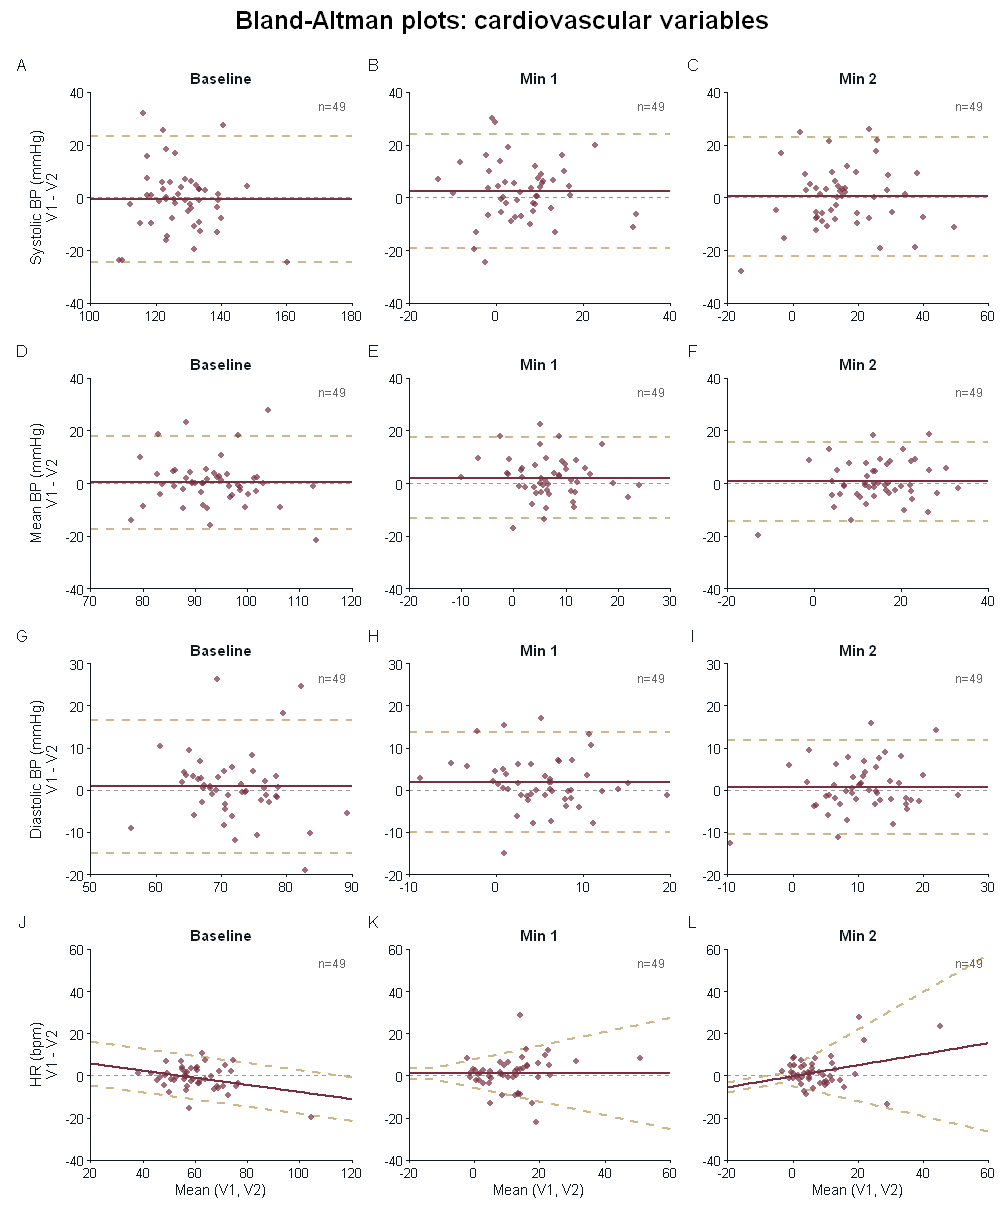

In [4]:
p2 <- build_ba_grid_gg(df, fig2_fig3_vars[1:4, ], "Bland-Altman plots: cardiovascular variables")
preview(p2, "Fig2_BA_Cardiovascular")
save_fig(p2, "Fig2_BA_Cardiovascular", figure_dims$Fig2_BA_Cardiovascular[["width"]], figure_dims$Fig2_BA_Cardiovascular[["height"]], config)

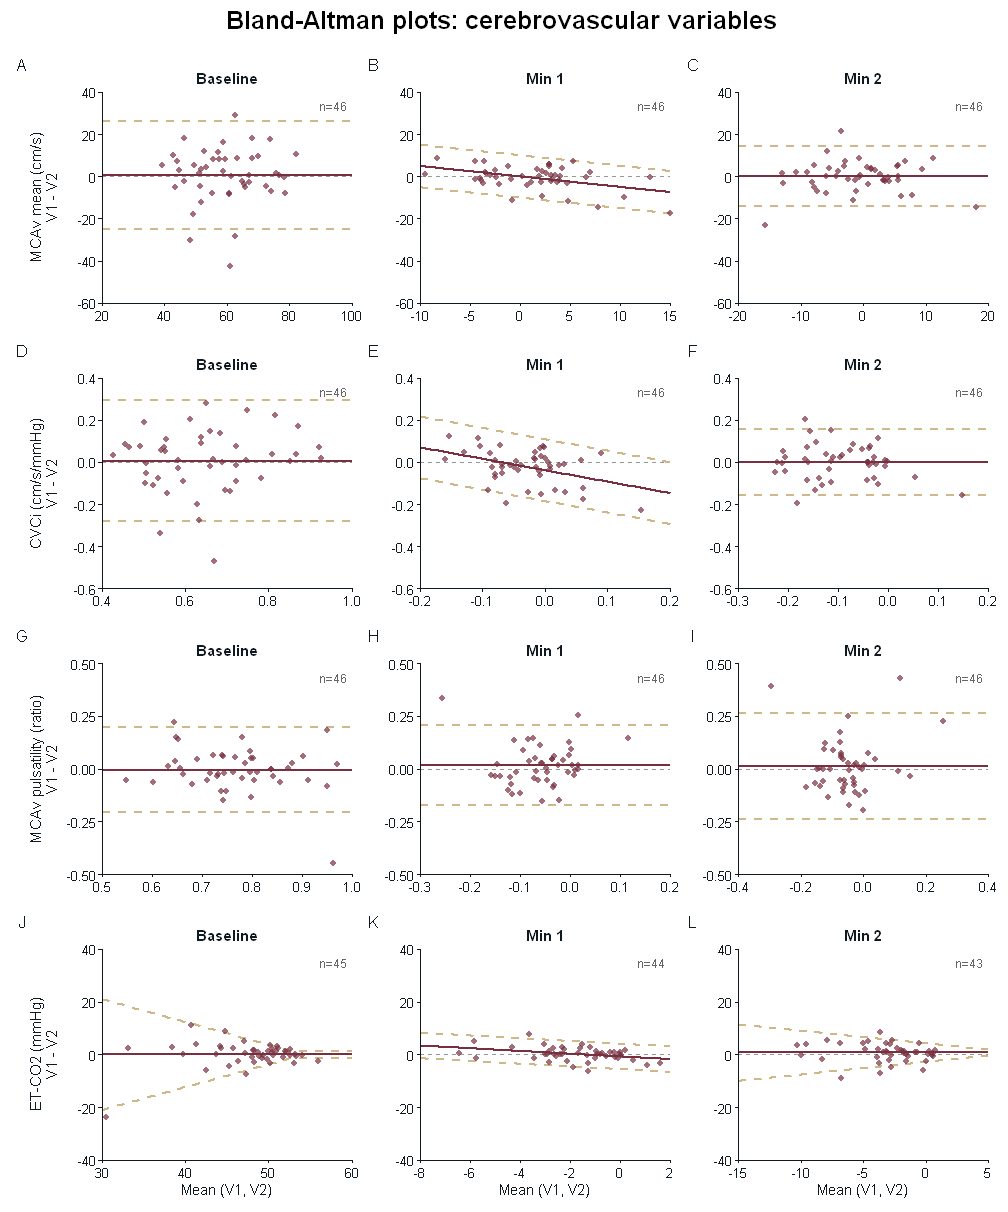

In [5]:
p3 <- build_ba_grid_gg(df, fig2_fig3_vars[5:8, ], "Bland-Altman plots: cerebrovascular variables")
preview(p3, "Fig3_BA_Cerebrovascular")
save_fig(p3, "Fig3_BA_Cerebrovascular", figure_dims$Fig3_BA_Cerebrovascular[["width"]], figure_dims$Fig3_BA_Cerebrovascular[["height"]], config)

## Fig4 / Fig6 - ICC/CCC reliability summary

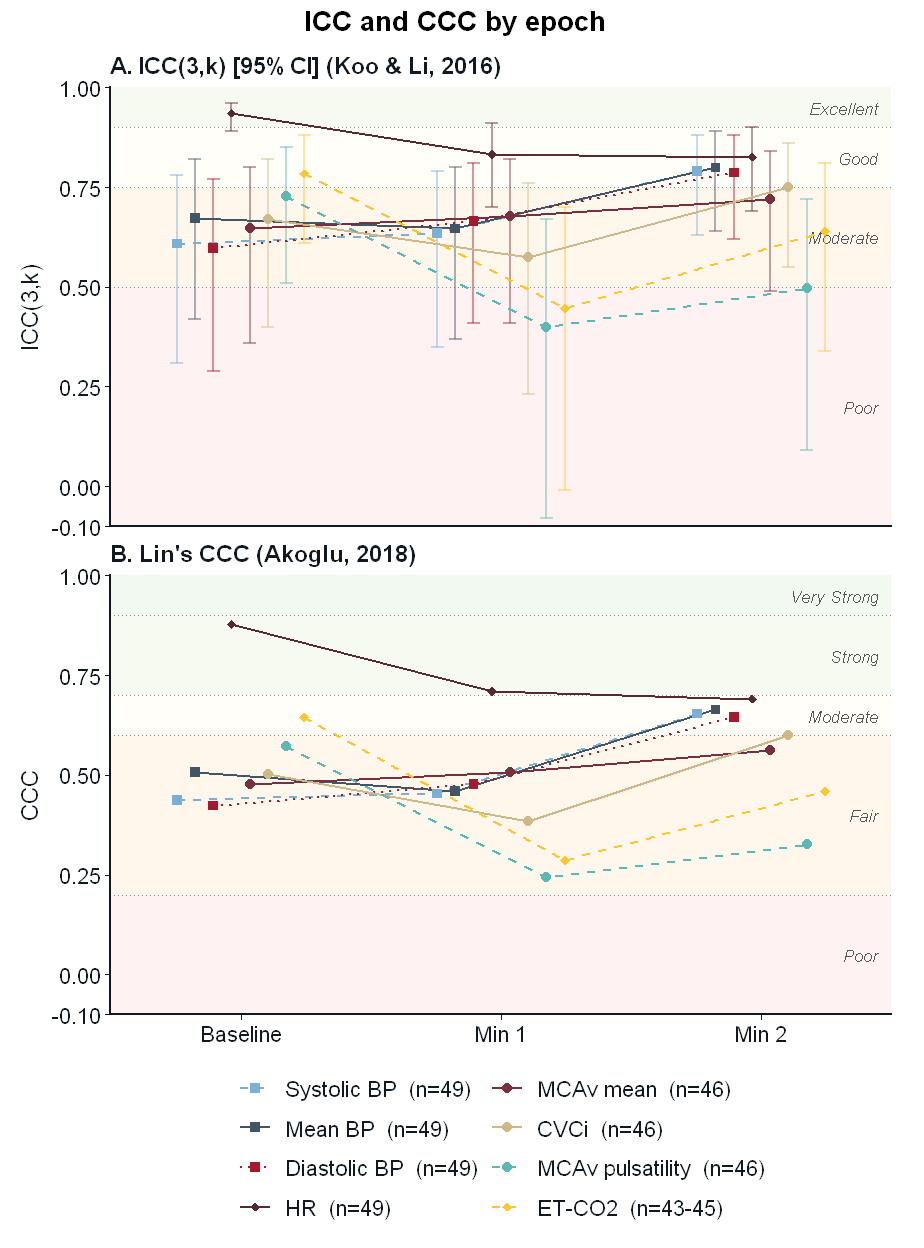

In [6]:
p4 <- build_reliability_summary_gg(stats_df, fig2_fig3_vars, "ICC and CCC by epoch", y_min = -0.10)
preview(p4, "Fig4_ICC_CCC_Summary")
save_fig(p4, "Fig4_ICC_CCC_Summary", figure_dims$Fig4_ICC_CCC_Summary[["width"]], figure_dims$Fig4_ICC_CCC_Summary[["height"]], config)

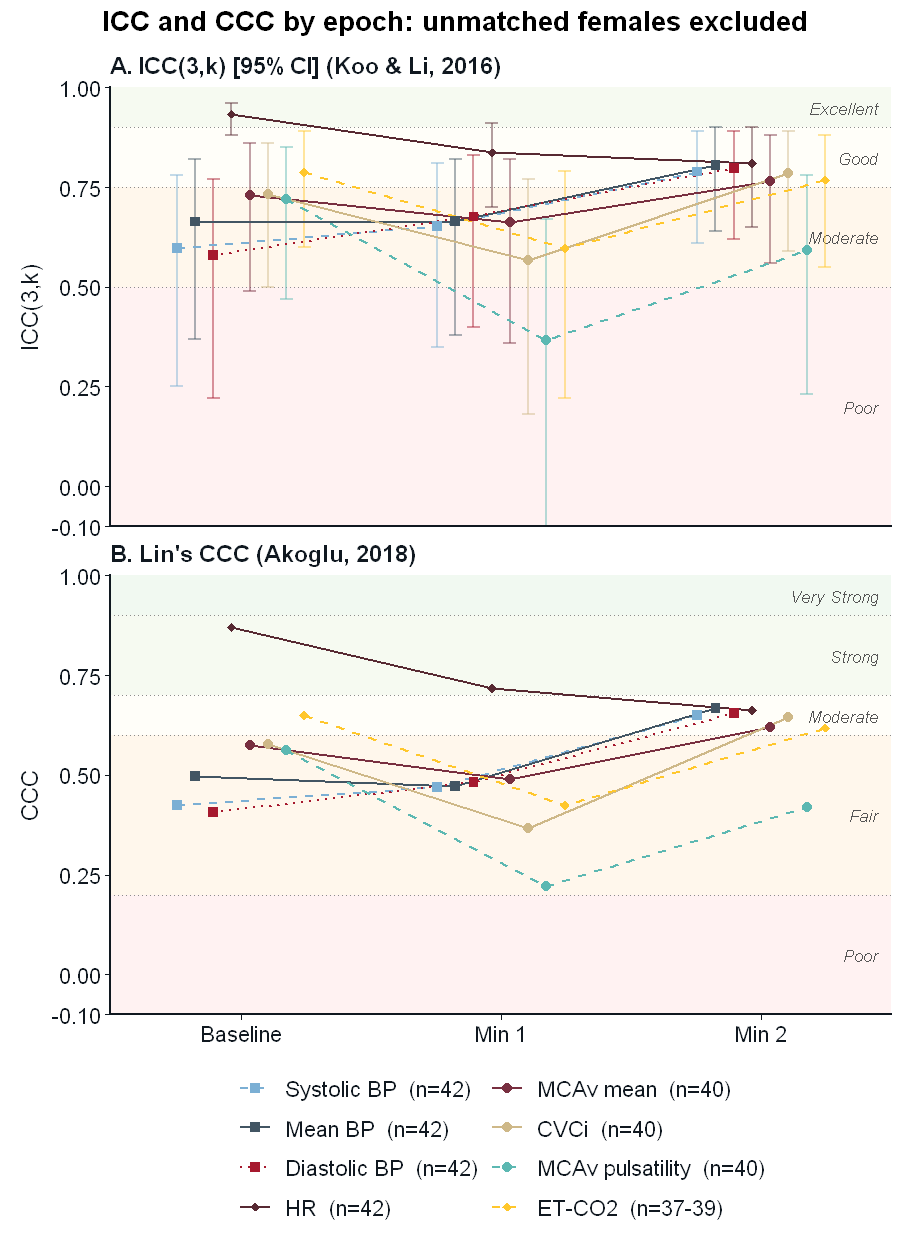

In [7]:
p6 <- build_reliability_summary_gg(fig6_df, fig2_fig3_vars, "ICC and CCC by epoch: unmatched females excluded", y_min = -0.10)
preview(p6, "Fig6_ICC_CCC_Exclude_Unmatched_Females")
save_fig(p6, "Fig6_ICC_CCC_Exclude_Unmatched_Females", figure_dims$Fig6_ICC_CCC_Exclude_Unmatched_Females[["width"]], figure_dims$Fig6_ICC_CCC_Exclude_Unmatched_Females[["height"]], config)

## Fig5 - reliability by sex and menstrual-cycle matching

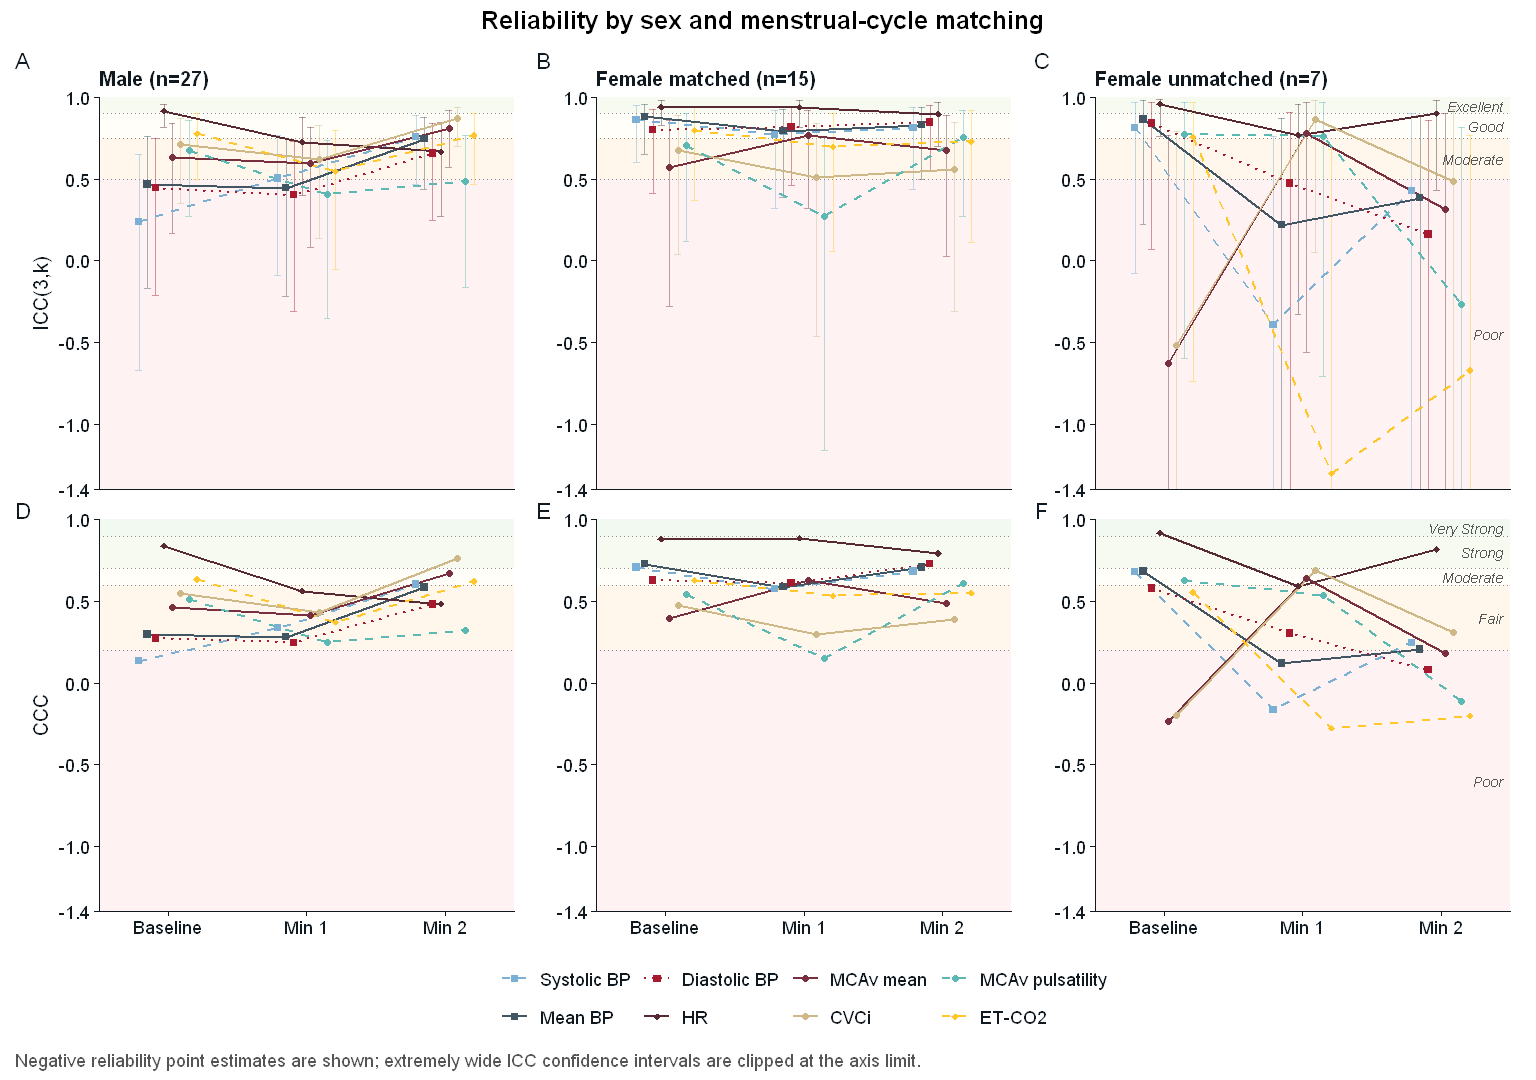

In [8]:
p5 <- build_fig5_gg(sex_df, fig2_fig3_vars)
preview(p5, "Fig5_ICC_CCC_Sex_Menstrual")
save_fig(p5, "Fig5_ICC_CCC_Sex_Menstrual", figure_dims$Fig5_ICC_CCC_Sex_Menstrual[["width"]], figure_dims$Fig5_ICC_CCC_Sex_Menstrual[["height"]], config)

## SupFig1 - ICC/CCC summary for all 15 variables

In [ ]:
p_sup1 <- build_reliability_summary_gg(
  stats_df, all15, "ICC and CCC by epoch: all variables", y_min = -0.10,
  theme_spec = figs_theme, annot_size = FIGS_ANNOT_SIZE, suptitle_size = FIGS_SUPTITLE_SIZE,
  legend_ncol = 5, offset_step = 0.045, point_size = 1.8, line_width = 0.6,
  show_n_in_legend = FALSE,
  caption = "n = 41-49 depending on variable and epoch; see Table 2 and Table 3 for per-variable n.",
  caption_size = FIGS_CAPTION_SIZE
)
preview(p_sup1, "SupFig1_ICC_CCC_AllVars")
save_fig(p_sup1, "SupFig1_ICC_CCC_AllVars", figure_dims$SupFig1_ICC_CCC_AllVars[["width"]], figure_dims$SupFig1_ICC_CCC_AllVars[["height"]], config)
# dims: 10.5 x 9.5 in

## SupFig2 - Bland-Altman plots: MCAv peak, MCAv min, CVRi, SmO2

In [ ]:
sup2_vars <- tibble::tribble(
  ~var_key,    ~stem,            ~label,       ~units,
  "mcav_peak", "MCAv peak",      "MCAv peak",  "cm/s",
  "mcav_min",  "MCAv minimum",   "MCAv min",   "cm/s",
  "cvri",      "MCAv Resis",     "CVRi",       "mmHg·s/cm",
  "smo2",      "SmO2",           "SmO2",       "%"
)
p_sup2 <- build_ba_grid_gg(df, sup2_vars,
                            "Bland-Altman plots: MCAv peak, MCAv min, CVRi, and SmO2")
preview(p_sup2, "SupFig2_BA_MCAv_CVRi_SmO2")
save_fig(p_sup2, "SupFig2_BA_MCAv_CVRi_SmO2", figure_dims$SupFig2_BA_MCAv_CVRi_SmO2[["width"]], figure_dims$SupFig2_BA_MCAv_CVRi_SmO2[["height"]], config)

## Full pipeline check

`render_all_figures_r()` is the batch entry point used by `run_step_06_render_figures.R`. Running
it here confirms it reproduces the same 7 figures previewed above.

In [10]:
render_all_figures_r(df, config)

for (name in names(figure_dims)) {
  png_path <- file.path(config$output_dir, paste0(name, ".png"))
  pdf_path <- file.path(config$output_dir, paste0(name, ".pdf"))
  cat("Rendered:", png_path, "(", file.info(png_path)$size, "bytes)\n")
  cat("Rendered:", pdf_path, "(", file.info(pdf_path)$size, "bytes)\n")
}

Rendered: C:/Users/Jonathan/OneDrive - Florida State University/MANUSCRIPTS/Write_TCD/A-TCD-git/Analysis_R/outputs/Fig1_CPT_TimeCourse.png ( 284124 bytes)
Rendered: C:/Users/Jonathan/OneDrive - Florida State University/MANUSCRIPTS/Write_TCD/A-TCD-git/Analysis_R/outputs/Fig1_CPT_TimeCourse.pdf ( 95232 bytes)
Rendered: C:/Users/Jonathan/OneDrive - Florida State University/MANUSCRIPTS/Write_TCD/A-TCD-git/Analysis_R/outputs/Fig2_BA_Cardiovascular.png ( 200674 bytes)
Rendered: C:/Users/Jonathan/OneDrive - Florida State University/MANUSCRIPTS/Write_TCD/A-TCD-git/Analysis_R/outputs/Fig2_BA_Cardiovascular.pdf ( 64878 bytes)
Rendered: C:/Users/Jonathan/OneDrive - Florida State University/MANUSCRIPTS/Write_TCD/A-TCD-git/Analysis_R/outputs/Fig3_BA_Cerebrovascular.png ( 197222 bytes)
Rendered: C:/Users/Jonathan/OneDrive - Florida State University/MANUSCRIPTS/Write_TCD/A-TCD-git/Analysis_R/outputs/Fig3_BA_Cerebrovascular.pdf ( 65880 bytes)
Rendered: C:/Users/Jonathan/OneDrive - Florida State Univer